# Example: brownfield design optimisation at different resolutions

In [18]:
import calliope
import pandas as pd
from plotting_utilities import plot_dispatch, plot_capacity, plot_network

calliope.set_log_verbosity('INFO', include_solver_output=False) # Defines how much information you get from the machine as the model gets built and run

## 1. Simple run to find cost-optimal system design at different resolutions
### 1.1 Default spatial resolution

In [19]:
# Load the model from the model.yaml file with a 'brownfield' design scenario, starting from current installed capacities
model = calliope.read_yaml('model_files/model.yaml', scenario='brownfield_capacities')

[2026-02-26 16:56:02] INFO     (scenarios, brownfield_capacities ) | Applying the following overrides: ['brownfield_capacities'].
[2026-02-26 16:56:02] INFO     Math init | loading pre-defined math.
[2026-02-26 16:56:02] INFO     Math init | loading math files {'milp', 'storage_inter_cluster', 'base', 'operate', 'additional_math', 'spores'}.
[2026-02-26 16:56:02] INFO     Model: preprocessing data
[2026-02-26 16:56:02] INFO     Math build | building applied math with ['base', 'additional_math'].
[2026-02-26 16:56:11] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:56:11] INFO     Model: initialisation complete


In [20]:
# Solve the model in 'planning' mode to find the cost-optimal system design
model.build()
model.solve()

[2026-02-26 16:56:11] INFO     Model: backend build starting
[2026-02-26 16:56:11] INFO     Optimisation Model | parameters/lookups | Generated.
[2026-02-26 16:56:12] INFO     Optimisation Model | variables | Generated.
[2026-02-26 16:56:16] INFO     Optimisation Model | global_expressions | Generated.
[2026-02-26 16:56:26] INFO     Optimisation Model | constraints | Generated.
[2026-02-26 16:56:26] INFO     Optimisation Model | piecewise_constraints | Generated.
[2026-02-26 16:56:26] INFO     Optimisation Model | objectives | Generated.
[2026-02-26 16:56:26] INFO     Model: backend build complete
[2026-02-26 16:56:32] INFO     Optimisation model | starting model in base mode.
[2026-02-26 16:56:52] INFO     Backend: solver finished running. Time since start of solving optimisation problem: 0:00:19.291589
[2026-02-26 16:56:52] INFO     Postprocessing: applied zero threshold 1e-10 to model results.
[2026-02-26 16:56:52] INFO     Postprocessing: ended. Time since start of solving optimisa

In [21]:
# Save outputs to NetCDF file
model.to_netcdf('results/cost-optimal-design.nc')

In [22]:
# If opening this notebook later, you can then just re-load the saved NetCDF file with all results
model = calliope.read_netcdf('results/cost-optimal-design.nc')

[2026-02-26 16:56:53] INFO     Model: preprocessing data (reentry)
[2026-02-26 16:56:53] INFO     Math build | building applied math with ['base', 'additional_math'].
[2026-02-26 16:56:53] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:56:53] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:56:53] INFO     Model: initialisation complete


### 1.2 Province-aggregated resolution

In [23]:
# Repeat the whole process for the NUTS2 version of the model, so that we can later compare the two
nuts2_model = calliope.read_yaml('model_files/nuts2_model.yaml', scenario='brownfield_capacities')
nuts2_model.build()
nuts2_model.solve()
nuts2_model.to_netcdf('results/cost-optimal-design_nuts2.nc')

[2026-02-26 16:56:54] INFO     (scenarios, brownfield_capacities ) | Applying the following overrides: ['brownfield_capacities'].
[2026-02-26 16:56:54] INFO     Math init | loading pre-defined math.
[2026-02-26 16:56:54] INFO     Math init | loading math files {'milp', 'storage_inter_cluster', 'base', 'operate', 'additional_math', 'spores'}.
[2026-02-26 16:56:54] INFO     Model: preprocessing data
[2026-02-26 16:56:54] INFO     Math build | building applied math with ['base', 'additional_math'].
[2026-02-26 16:56:58] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:56:58] INFO     Model: initialisation complete
[2026-02-26 16:56:58] INFO     Model: backend build starting
[2026-02-26 16:56:59] INFO     Optimisation Model | parameters/lookups | Generated.
[2026-02-26 16:56:59] INFO     Optimisation Model | variables | Generated.
[2026-02-26 16:57:02] INFO     Optimisation Model | global_expressions | Generated.
[2

In [24]:
# If opening this notebook later, you can then just re-load the saved NetCDF file with all results
nuts2_model = calliope.read_netcdf('results/cost-optimal-design_nuts2.nc')

[2026-02-26 16:57:26] INFO     Model: preprocessing data (reentry)
[2026-02-26 16:57:26] INFO     Math build | building applied math with ['base', 'additional_math'].
[2026-02-26 16:57:27] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:57:27] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:57:27] INFO     Model: initialisation complete


## 2. Analyse and compare the results
### 2.1 High-level cost metrics

In [25]:
cost = round(float((model.results.cost.sel(costs='monetary').sum(['nodes','techs']).values)))/1e3
nuts2_cost = round(float((nuts2_model.results.cost.sel(costs='monetary').sum(['nodes','techs']).values)))/1e3

print("""
      The total annualised system cost for the optimal design is {} Million EUR/year based on the 
      highly-resolved model version. When using the province-aggregated version of the model, 
      the cost is {} Million EUR/year.
      """.format(cost,nuts2_cost)
     )


      The total annualised system cost for the optimal design is 705.419 Million EUR/year based on the 
      highly-resolved model version. When using the province-aggregated version of the model, 
      the cost is 664.651 Million EUR/year.
      


In [26]:
# The average shadow price in the highly-resolved model
model.results.shadow_price_system_balance.mean('timesteps').to_series()

nodes    carriers
BE       power       0.046561
DE       power       0.046560
DK       power       0.046531
GB       power       0.046567
NL111    power       0.046060
NL112    power       0.046028
NL113    power       0.046047
NL124_1  power       0.042366
NL126    power       0.042348
NL131_2  power       0.046145
NL211_1  power       0.046162
NL213    power       0.046507
NL221_2  power       0.046566
NL225    power       0.046557
NL230    power       0.046089
NL310    power       0.046150
NL321_2  power       0.046196
NL323_3  power       0.046179
NL332_3  power       0.046196
NL333    power       0.046146
NL33A    power       0.046142
NL341_1  power       0.046437
NL411_1  power       0.046523
NL413    power       0.046565
NL414    power       0.046555
NL421_2  power       0.046566
NO       power       0.046569
Name: shadow_price_system_balance, dtype: float64

In [27]:
# The average shadow price in the province-aggregated model
nuts2_model.results.shadow_price_system_balance.mean('timesteps').to_series()

nodes  carriers
BEL    power       0.046496
DEU    power       0.046503
DNK    power       0.046466
GBR    power       0.046523
NL11   power       0.046275
NL12   power       0.042425
NL13   power       0.046214
NL21   power       0.046414
NL22   power       0.046483
NL23   power       0.046347
NL31   power       0.046414
NL32   power       0.046445
NL33   power       0.046415
NL34   power       0.046381
NL41   power       0.046483
NL42   power       0.046484
NOR    power       0.046557
Name: shadow_price_system_balance, dtype: float64

### 2.2 Inspect the results visually

In [28]:
# First, let's load consistent colours and names for our technologies
df = pd.read_csv('model_files/techs_and_nodes/tech_names_and_colours.csv')
colours = dict(zip(df['technology_id'], df['color']))

In [29]:
# Visual difference in the dispatch
plot_dispatch('results/cost-optimal-design.nc', exclude_transmission=True, colors=colours)

[2026-02-26 16:57:28] INFO     Model: preprocessing data (reentry)
[2026-02-26 16:57:28] INFO     Math build | building applied math with ['base', 'additional_math'].
[2026-02-26 16:57:28] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:57:29] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:57:29] INFO     Model: initialisation complete


In [30]:
plot_dispatch('results/cost-optimal-design_nuts2.nc', exclude_transmission=True, colors=colours)

[2026-02-26 16:57:29] INFO     Model: preprocessing data (reentry)
[2026-02-26 16:57:29] INFO     Math build | building applied math with ['base', 'additional_math'].
[2026-02-26 16:57:29] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:57:30] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:57:30] INFO     Model: initialisation complete


In [31]:
plot_capacity('results/cost-optimal-design.nc', exclude_transmission=True, colors=colours)

[2026-02-26 16:57:30] INFO     Model: preprocessing data (reentry)
[2026-02-26 16:57:30] INFO     Math build | building applied math with ['base', 'additional_math'].
[2026-02-26 16:57:31] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:57:31] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:57:31] INFO     Model: initialisation complete


In [32]:
plot_capacity('results/cost-optimal-design_nuts2.nc', exclude_transmission=True, colors=colours)

[2026-02-26 16:57:32] INFO     Model: preprocessing data (reentry)
[2026-02-26 16:57:32] INFO     Math build | building applied math with ['base', 'additional_math'].
[2026-02-26 16:57:32] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:57:33] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:57:33] INFO     Model: initialisation complete


[2026-02-26 16:57:34] INFO     Model: preprocessing data (reentry)
[2026-02-26 16:57:34] INFO     Math build | building applied math with ['base', 'additional_math'].
[2026-02-26 16:57:34] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:57:34] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:57:34] INFO     Model: initialisation complete


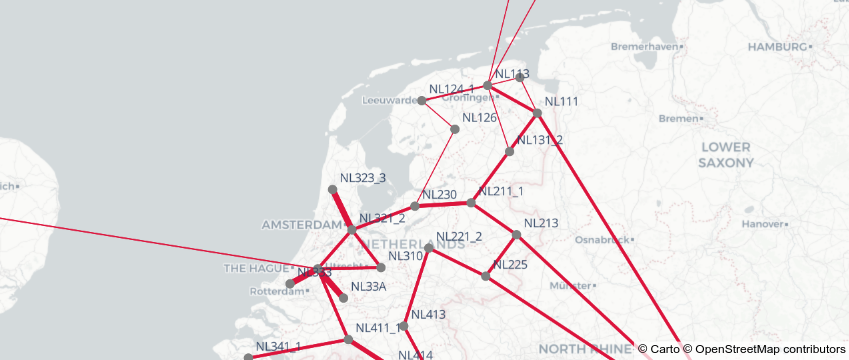

In [33]:
plot_network('results/cost-optimal-design.nc')

[2026-02-26 16:57:35] INFO     Model: preprocessing data (reentry)
[2026-02-26 16:57:35] INFO     Math build | building applied math with ['base', 'additional_math'].
[2026-02-26 16:57:35] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:57:36] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 16:57:36] INFO     Model: initialisation complete


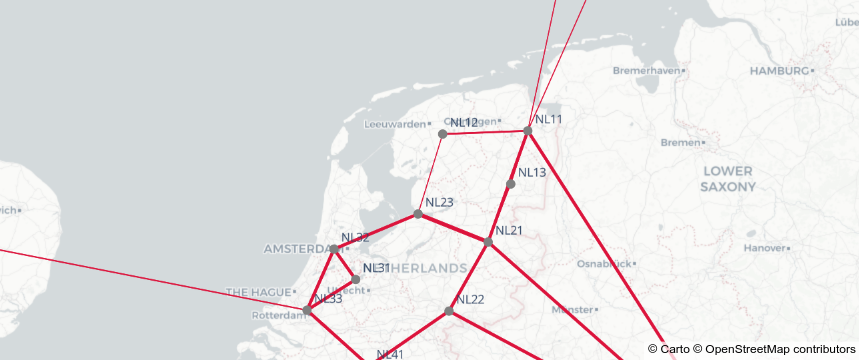

In [34]:
plot_network('results/cost-optimal-design_nuts2.nc')